#### Problem Statement

 Load the load_digit dataset from sklearn.datasets.  
This dataset is made up of 1797 8x8 images. Each image, is of a hand-written digit. Therefore, each training 
example has 64 features (8X8) pixel values. Hence, the size of dataset is 1797X64.  
Implement SVD in the following two ways: 
<br> (a) Step-by-step  
<br> (b) Using inbuilt SVD function in python

In [1]:
from sklearn.datasets import load_digits

In [2]:
digits = load_digits()

In [3]:
import numpy as np
matrix = np.array(digits.data)
matrix,matrix.shape

(array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 (1797, 64))

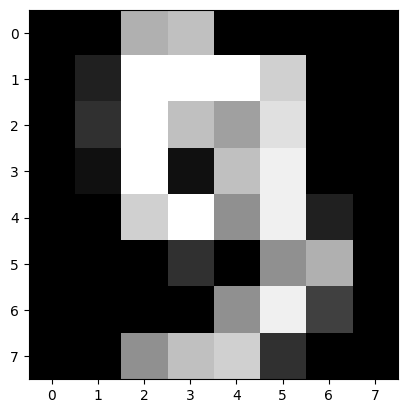

In [4]:
import matplotlib.pyplot as plt
plt.imshow(digits.images[9],cmap="grey")
plt.show()

In [5]:
matrix_Transpose = np.transpose(matrix)
matrix_Transpose,matrix_Transpose.shape

(array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 5.,  0.,  0., ...,  1.,  2., 10.],
        ...,
        [ 0., 10., 16., ...,  6., 12., 12.],
        [ 0.,  0.,  9., ...,  0.,  0.,  1.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]),
 (64, 1797))

In [6]:
aat = np.matmul(matrix,matrix_Transpose)
aat,aat.shape

(array([[3070., 1866., 2264., ..., 2812., 3006., 2898.],
        [1866., 4209., 3432., ..., 3906., 3083., 3307.],
        [2264., 3432., 4388., ..., 4005., 3063., 3697.],
        ...,
        [2812., 3906., 4005., ..., 5092., 3729., 4598.],
        [3006., 3083., 3063., ..., 3729., 4316., 3850.],
        [2898., 3307., 3697., ..., 4598., 3850., 4938.]]),
 (1797, 1797))

In [7]:
values,vectors = np.linalg.eigh(aat)
vectors,vectors.shape

(array([[-1.01350445e-06,  0.00000000e+00,  0.00000000e+00, ...,
          3.89296445e-02, -2.10250887e-03, -2.09114372e-02],
        [-6.34057303e-01,  1.25220381e-01, -3.66020270e-03, ...,
         -3.77989154e-02,  1.38656341e-02, -2.53199533e-02],
        [-1.02464218e-01,  5.14881721e-01,  2.27773937e-01, ...,
         -1.78272413e-02,  1.21951237e-02, -2.54559261e-02],
        ...,
        [-4.71205177e-02, -3.10177386e-02, -3.36495601e-02, ...,
         -1.16134751e-02,  1.87985701e-02, -2.98784403e-02],
        [ 2.80252919e-02, -5.50558356e-03, -2.71782002e-02, ...,
          2.34742370e-02, -8.66186959e-03, -2.67227437e-02],
        [-2.08054874e-02, -1.86070599e-03,  7.95443912e-03, ...,
          1.29922129e-02, -8.03379300e-04, -2.93865591e-02]]),
 (1797, 1797))

In [8]:
values,len(values)

(array([-4.12203271e-10, -2.32084056e-10, -1.76093584e-10, ...,
         2.93769347e+05,  3.21485339e+05,  4.80977243e+06]),
 1797)

In [9]:
values = np.clip(values,0,None)
values

array([      0.        ,       0.        ,       0.        , ...,
        293769.34713479,  321485.33927159, 4809772.4255891 ])

In [10]:
desc = values[::-1]
desc

array([4809772.4255891 ,  321485.33927159,  293769.34713479, ...,
             0.        ,       0.        ,       0.        ])

In [11]:
idx = np.argsort(values)
idx = idx[::-1]
idx
##we get indices for sorting
##np.argsort(values) returns a list for sorting in ascending
##we reverse the list to sort in desc

array([1796, 1795, 1794, ...,  611,  610,    0], dtype=int64)

In [12]:
desc = values[idx]
desc

array([4809772.4255891 ,  321485.33927159,  293769.34713479, ...,
             0.        ,       0.        ,       0.        ])

In [13]:
u = vectors[:,idx]
u

array([[-2.09114372e-02, -2.10250887e-03,  3.89296445e-02, ...,
         0.00000000e+00,  0.00000000e+00, -1.01350445e-06],
       [-2.53199533e-02,  1.38656341e-02, -3.77989154e-02, ...,
        -1.83538207e-04, -8.97671633e-04, -6.34057303e-01],
       [-2.54559261e-02,  1.21951237e-02, -1.78272413e-02, ...,
        -5.82326445e-04, -3.29021569e-03, -1.02464218e-01],
       ...,
       [-2.98784403e-02,  1.87985701e-02, -1.16134751e-02, ...,
        -2.69964551e-02, -7.16040318e-03, -4.71205177e-02],
       [-2.67227437e-02, -8.66186959e-03,  2.34742370e-02, ...,
        -4.10253412e-02, -4.65719870e-03,  2.80252919e-02],
       [-2.93865591e-02, -8.03379300e-04,  1.29922129e-02, ...,
         3.69461696e-04, -1.11929470e-02, -2.08054874e-02]])

In [14]:
sigma = np.zeros(matrix.shape)

In [15]:
last_eigen_value_index = matrix.shape[1]
last_eigen_value_index

64

In [16]:
for i in range(0,last_eigen_value_index):
    sigma[i][i] = np.sqrt(desc[i])
sigma

array([[2193.11933683,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,  566.99677184,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,  542.00493276, ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ]])

In [17]:
ata = np.matmul(matrix_Transpose,matrix)
ata,ata.shape

(array([[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [0.00000e+00, 1.64400e+03, 7.15400e+03, ..., 3.40600e+03,
         1.30600e+03, 6.60000e+01],
        [0.00000e+00, 7.15400e+03, 8.92850e+04, ..., 6.11890e+04,
         2.18770e+04, 4.72000e+03],
        ...,
        [0.00000e+00, 3.40600e+03, 6.11890e+04, ..., 1.44749e+05,
         5.32400e+04, 9.59500e+03],
        [0.00000e+00, 1.30600e+03, 2.18770e+04, ..., 5.32400e+04,
         3.77360e+04, 9.83300e+03],
        [0.00000e+00, 6.60000e+01, 4.72000e+03, ..., 9.59500e+03,
         9.83300e+03, 6.45300e+03]]),
 (64, 64))

In [18]:
values,vectors = np.linalg.eigh(ata)
vectors,vectors.shape

(array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -9.85740003e-03,  1.73619371e-02,  5.77192878e-03],
        [ 0.00000000e+00,  1.21707717e-15, -1.64953041e-14, ...,
         -4.48071690e-02,  2.24200800e-01,  1.00696020e-01],
        ...,
        [ 0.00000000e+00, -1.14546632e-15, -2.30717158e-14, ...,
          1.83210572e-01,  9.01286131e-02,  1.30885120e-01],
        [ 0.00000000e+00,  6.63464987e-16,  2.21243431e-16, ...,
          2.14953332e-02,  3.68410903e-02,  3.92343661e-02],
        [ 0.00000000e+00, -3.57162986e-15, -1.39740166e-14, ...,
         -6.40453868e-03,  1.15150706e-02,  6.76004954e-03]]),
 (64, 64))

In [19]:
values, len(values)

(array([0.00000000e+00, 2.52923683e-12, 3.19114079e-11, 7.40483783e-01,
        1.18769998e+00, 2.29473726e+00, 6.51802535e+00, 1.52320304e+01,
        2.68560500e+01, 7.12408703e+01, 1.09105659e+02, 1.13894087e+02,
        1.78092033e+02, 4.53277596e+02, 8.73520246e+02, 1.20868886e+03,
        1.67263380e+03, 2.08149125e+03, 2.32172941e+03, 2.51877073e+03,
        3.03690335e+03, 3.27211395e+03, 3.42595219e+03, 4.10076575e+03,
        4.57731894e+03, 4.80069248e+03, 4.91796717e+03, 5.54416940e+03,
        6.34448957e+03, 6.68199580e+03, 7.08239495e+03, 7.27368614e+03,
        7.65227999e+03, 8.06923191e+03, 9.26122989e+03, 1.05839585e+04,
        1.11895066e+04, 1.24304601e+04, 1.29144454e+04, 1.50373514e+04,
        1.56141117e+04, 1.65923341e+04, 1.72537673e+04, 1.94152210e+04,
        2.10061638e+04, 2.19837248e+04, 2.73737001e+04, 2.91890728e+04,
        3.05385115e+04, 3.45170154e+04, 3.88137451e+04, 4.30961663e+04,
        5.02498538e+04, 5.22834621e+04, 7.21026932e+04, 7.815209

In [20]:
values = np.clip(values,0,None)
values

array([0.00000000e+00, 2.52923683e-12, 3.19114079e-11, 7.40483783e-01,
       1.18769998e+00, 2.29473726e+00, 6.51802535e+00, 1.52320304e+01,
       2.68560500e+01, 7.12408703e+01, 1.09105659e+02, 1.13894087e+02,
       1.78092033e+02, 4.53277596e+02, 8.73520246e+02, 1.20868886e+03,
       1.67263380e+03, 2.08149125e+03, 2.32172941e+03, 2.51877073e+03,
       3.03690335e+03, 3.27211395e+03, 3.42595219e+03, 4.10076575e+03,
       4.57731894e+03, 4.80069248e+03, 4.91796717e+03, 5.54416940e+03,
       6.34448957e+03, 6.68199580e+03, 7.08239495e+03, 7.27368614e+03,
       7.65227999e+03, 8.06923191e+03, 9.26122989e+03, 1.05839585e+04,
       1.11895066e+04, 1.24304601e+04, 1.29144454e+04, 1.50373514e+04,
       1.56141117e+04, 1.65923341e+04, 1.72537673e+04, 1.94152210e+04,
       2.10061638e+04, 2.19837248e+04, 2.73737001e+04, 2.91890728e+04,
       3.05385115e+04, 3.45170154e+04, 3.88137451e+04, 4.30961663e+04,
       5.02498538e+04, 5.22834621e+04, 7.21026932e+04, 7.81520967e+04,
      

In [21]:
idx = np.argsort(values)
idx = idx[::-1]
idx

array([63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47,
       46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30,
       29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13,
       12, 11, 10,  9,  8,  7,  6,  5,  4,  3,  2,  1,  0], dtype=int64)

In [22]:
desc = values[idx]
desc

array([4.80977243e+06, 3.21485339e+05, 2.93769347e+05, 2.54168934e+05,
       1.81129372e+05, 1.24763130e+05, 1.02640676e+05, 9.12489491e+04,
       7.81520967e+04, 7.21026932e+04, 5.22834621e+04, 5.02498538e+04,
       4.30961663e+04, 3.88137451e+04, 3.45170154e+04, 3.05385115e+04,
       2.91890728e+04, 2.73737001e+04, 2.19837248e+04, 2.10061638e+04,
       1.94152210e+04, 1.72537673e+04, 1.65923341e+04, 1.56141117e+04,
       1.50373514e+04, 1.29144454e+04, 1.24304601e+04, 1.11895066e+04,
       1.05839585e+04, 9.26122989e+03, 8.06923191e+03, 7.65227999e+03,
       7.27368614e+03, 7.08239495e+03, 6.68199580e+03, 6.34448957e+03,
       5.54416940e+03, 4.91796717e+03, 4.80069248e+03, 4.57731894e+03,
       4.10076575e+03, 3.42595219e+03, 3.27211395e+03, 3.03690335e+03,
       2.51877073e+03, 2.32172941e+03, 2.08149125e+03, 1.67263380e+03,
       1.20868886e+03, 8.73520246e+02, 4.53277596e+02, 1.78092033e+02,
       1.13894087e+02, 1.09105659e+02, 7.12408703e+01, 2.68560500e+01,
      

In [23]:
v = vectors[:,idx]

In [24]:
v = np.transpose(v)
v

array([[ 0.00000000e+00,  5.77192878e-03,  1.00696020e-01, ...,
         1.30885120e-01,  3.92343661e-02,  6.76004954e-03],
       [ 0.00000000e+00,  1.73619371e-02,  2.24200800e-01, ...,
         9.01286131e-02,  3.68410903e-02,  1.15150706e-02],
       [ 0.00000000e+00, -9.85740003e-03, -4.48071690e-02, ...,
         1.83210572e-01,  2.14953332e-02, -6.40453868e-03],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -1.64953041e-14, ...,
        -2.30717158e-14,  2.21243431e-16, -1.39740166e-14],
       [ 0.00000000e+00,  0.00000000e+00,  1.21707717e-15, ...,
        -1.14546632e-15,  6.63464987e-16, -3.57162986e-15],
       [ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [28]:
sigma,desc

(array([[2193.11933683,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,  566.99677184,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,    0.        ,  542.00493276, ...,    0.        ,
            0.        ,    0.        ],
        ...,
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        , ...,    0.        ,
            0.        ,    0.        ]]),
 array([4.80977243e+06, 3.21485339e+05, 2.93769347e+05, 2.54168934e+05,
        1.81129372e+05, 1.24763130e+05, 1.02640676e+05, 9.12489491e+04,
        7.81520967e+04, 7.21026932e+04, 5.22834621e+04, 5.02498538e+04,
        4.30961663e+04, 3.88137451e+04, 3.45170154e+04, 3.05385115e+04,
        2.918